# Variable Definitions Reference
Display of all xmeas and xmvs variables with their actual names and units

In [1]:
import sys
import os
sys.path.insert(0, os.getcwd())

from docs import xmeas, xmvs
import pandas as pd
from IPython.display import HTML

# Create DataFrame for xmeas (measured variables)
xmeas_data = []
i = 0
for var_name, var_info in xmeas.items():
    i += 1
    xmeas_data.append({
        'Variable': var_name,
        'Name': var_info['name'],
        'Unit': var_info.get('unit', 'N/A'),
    })
print(i)
xmeas_df = pd.DataFrame(xmeas_data)

# Create DataFrame for xmvs (manipulated variables)
xmvs_data = []
for var_name, var_info in xmvs.items():
    xmvs_data.append({
        'Variable': var_name,
        'Name': var_info['name'],
        'Unit': var_info.get('unit', 'N/A'),
    })

xmvs_df = pd.DataFrame(xmvs_data)




73


In [ ]:
import os
os.chdir("data/")
import pandas as pd
df = pd.read_csv("dataset_name.csv")  # Change filename if needed


## Measured Variables (xmeas) names

In [3]:
HTML(xmeas_df.to_html(index=False))

Variable,Name,Unit
xmeas_1,A feed,kscmh
xmeas_2,D feed,kg/h
xmeas_3,E feed,kg/h
xmeas_4,A and C feed,kscmh
xmeas_5,Recycle flow,kscmh
xmeas_6,Reactor feed rate,kscmh
xmeas_7,Reactor pressure,kPa gauge
xmeas_8,Reactor level,%
xmeas_9,Reactor temperature,C
xmeas_10,Purge rate,kscmh


## Manipulated Variables (xmvs) names

In [4]:
HTML(xmvs_df.to_html(index=False))

Variable,Name,Unit
xmv_1,D Feed Flow,kg/h
xmv_2,E Feed Flow,kg/h
xmv_3,A Feed Flow,kscmh
xmv_4,A and C Feed Flow,kscmh
xmv_5,Compressor Recycle Valve,%
xmv_6,Purge Valve,%
xmv_7,Separator Pot Liquid Flow,m3/h
xmv_8,Stripper Liquid Product Flow,m3/h
xmv_9,Stripper Steam Valve,%
xmv_10,Reactor Cooling Water Flow,m3/h


## Sellect the Variable to show

In [5]:
COLUMN_NAME = "xmeas19"  # <-- Change this to any column name

Dataframe Shape: (rows: timeseries, columns: variable)
(10001, 85)


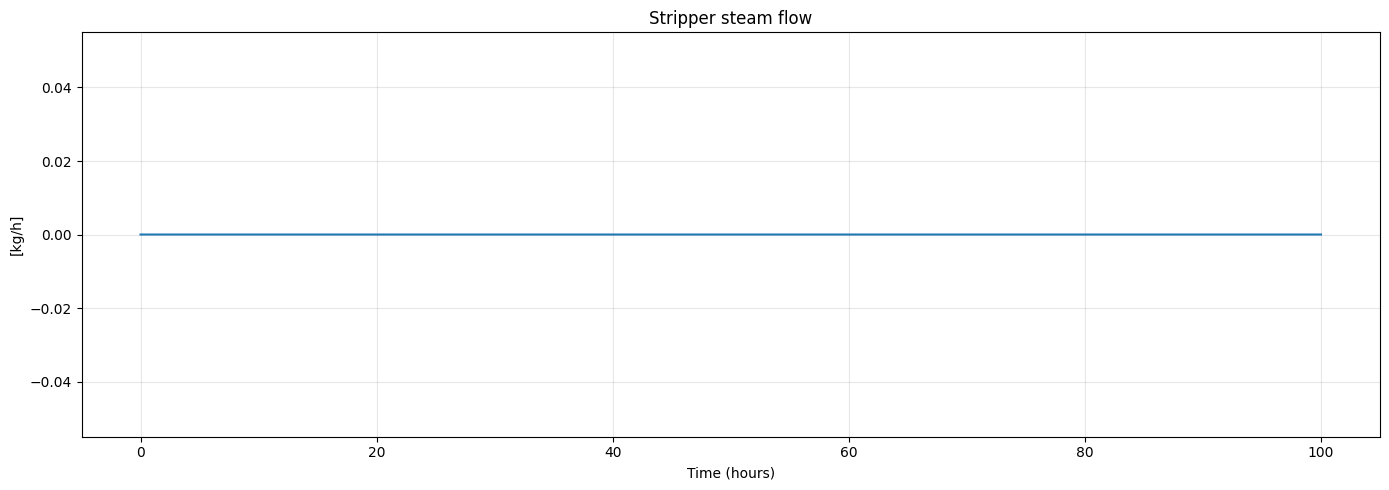

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset

print("Dataframe Shape: (rows: timeseries, columns: variable)")
print(df.shape)  # Print the shape of the DataFrame

# Create time array: 0 to 100 hours with 0.01 h sampling
time = np.linspace(0, 100, 10001)

# Get the data
data = df[COLUMN_NAME].values

# Convert column name to dictionary key format (e.g., xmeas2 -> xmeas_2)
if COLUMN_NAME.startswith('xmeas') and '_' not in COLUMN_NAME:
    dict_key = COLUMN_NAME[:5] + '_' + COLUMN_NAME[5:]  # xmeas2 -> xmeas_2
elif COLUMN_NAME.startswith('xmv') and '_' not in COLUMN_NAME:
    dict_key = COLUMN_NAME[:3] + '_' + COLUMN_NAME[3:]  # xmv1 -> xmv_1
else:
    dict_key = COLUMN_NAME

# Look up variable information from docs
if dict_key in xmeas:
    var_info = xmeas[dict_key]
    var_display_name = var_info['name']
    var_unit = var_info.get('unit', '')
elif dict_key in xmvs:
    var_info = xmvs[dict_key]
    var_display_name = var_info['name']
    var_unit = var_info.get('unit', '')
else:
    var_display_name = COLUMN_NAME
    var_unit = ''

# Create label with name and unit
if var_unit:
    y_label = f"[{var_unit}]"
    title = var_display_name
else:
    y_label = var_display_name
    title = var_display_name

# Plot
plt.figure(figsize=(14, 5))
plt.plot(time, data, linewidth=1.5)
plt.xlabel("Time (hours)")
plt.ylabel(y_label)
plt.title(title)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
